<a href="https://colab.research.google.com/github/abbynam/neur-265/blob/main/coding_homework_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Abby Nam
*NEUR265*

**2/28/26**

In [4]:
# import modules
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [6]:
# load csv as dataframe
url = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/patch_seq_expanded.csv'
patch_seq = pd.read_csv(url)

Text(0, 0.5, 'Count')

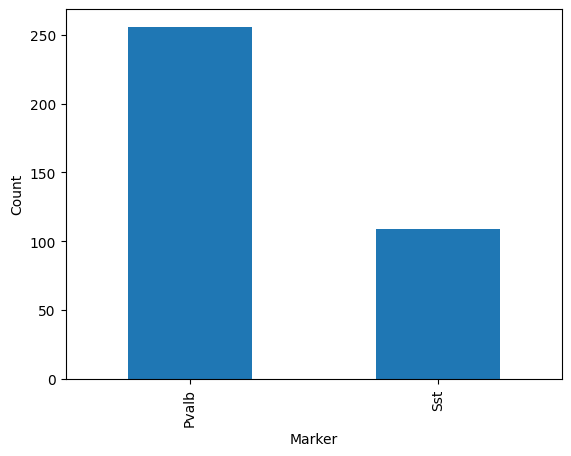

In [29]:
# bar graph of value counts for marker
marker_graph = patch_seq['Marker'].value_counts().plot(kind='bar')

# set labels
marker_graph.set_xlabel('Marker')
marker_graph.set_ylabel('Count')

<Axes: ylabel='count'>

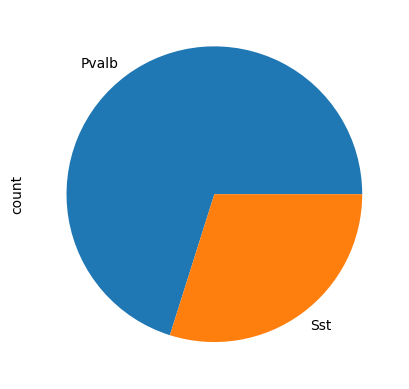

In [35]:
# pie chart of value counts for marker
patch_seq['Marker'].value_counts().plot(kind='pie')

Text(0, 0.5, 'Fast trough (mV)')

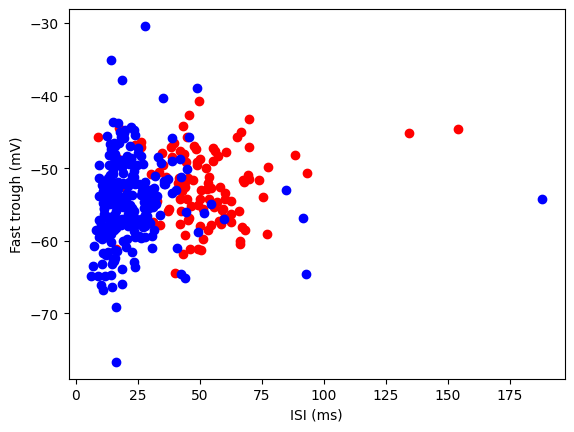

In [38]:
# use for loop to make ISI vs. Fast trough scatterplot

# find length of dataset
df_len = len(patch_seq)

# loop through e/ value
for i in range(df_len):
  # if the given row in the Marker column is Sst, plot ISI vs. FT red
  if patch_seq.iloc[i,2] == 'Sst':
    plt.scatter(patch_seq.iloc[i,0],patch_seq.iloc[i,1],color = "red")
  # otherwise pvalb, plot blue
  else:
    plt.scatter(patch_seq.iloc[i,0],patch_seq.iloc[i,1],color = "blue")

# axes labels
plt.xlabel('ISI (ms)')
plt.ylabel('Fast trough (mV)')

In [40]:
# make function to output scatterplot above

def patchScatter():
  """
  Outputs a scatterplot of ISI vs. fast trough values
  for Sst and Pvalb expressing neurons.
  """
  df_len = len(patch_seq)

  for i in range(df_len):
    if patch_seq.iloc[i,2] == 'Sst':
      plt.scatter(patch_seq.iloc[i,0],patch_seq.iloc[i,1],color = "red")
    else:
      plt.scatter(patch_seq.iloc[i,0],patch_seq.iloc[i,1],color = "blue")

  plt.xlabel('ISI (ms)')
  plt.ylabel('Fast trough (mV)')

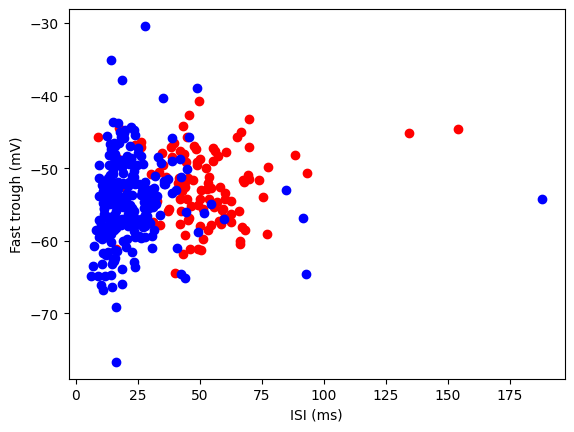

In [41]:
# call function
patchScatter()

In [42]:
# find descriptive stats for data
patch_seq.groupby('Marker')['Fast_Trough'].describe()

,count,mean,std,min,25%,50%,75%,max
Marker,,,,,,,,
Pvalb,256.0,-54.548074,5.870670,-76.687508,-57.914063,-54.490629,-51.364065,-30.406252
Sst,109.0,-52.514968,4.958103,-64.375008,-55.931252,-52.568752,-48.500000,-40.781254


Pvalb-expressing neurons have a more negative undershoot after an action potential because their mean is lower (more negative) than Sst-expressing neurons.

In [43]:
# find skewness of fast trough column
patch_seq.groupby('Marker')['Fast_Trough'].skew()

,Fast_Trough
Marker,
Pvalb,0.19536
Sst,0.00125


The fast trough values for both Sst- and Pvalb-expressing neurons are both very normally distributed.

In [44]:
# find skewness of ISIs
patch_seq.groupby('Marker')['ISI'].skew()

,ISI
Marker,
Pvalb,5.596386
Sst,1.857850


The ISIs for both Sst- and Pvalb-expressing neurons are both very positively skewed.  The Pvalb ISIs are even more skewed than the Sst ISIs.

In [45]:
# t-test for fast trough

# separate each group of neurons
sst_neurons = patch_seq[patch_seq['Marker']=='Sst']
pvalb_neurons = patch_seq[patch_seq['Marker']=='Pvalb']

# run t-test
stats.ttest_ind(sst_neurons['Fast_Trough'],pvalb_neurons['Fast_Trough'])


TtestResult(statistic=np.float64(3.1660773376899147), pvalue=np.float64(0.0016757984214133585), df=np.float64(363.0))

The undershoot voltage significantly differs between Sst- and Pvalb-expressing neurons, *p* = 0.002.

In [63]:
# run t-test for ISI
stats.ttest_ind(sst_neurons['ISI'],pvalb_neurons['ISI'])

TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.float64(nan))

Pvalb is missing some values for ISI, so the t-test is not returning a valid result.